In [21]:
# filename: load_trades.ipynb

import pandas as pd

# Path to the file (pc_sc_nl segment)
file_path = '/Users/buddy/Desktop/traderie/data/normalized/normalized_trades_pc_sc_nl.csv'

# Load the CSV into pandas
df = pd.read_csv(file_path)

# Show the first few rows
df.head()

,TradeID,Offered,Requested,NumAsks
0,Ist Rune_2025-05-21T04:09:00.288Z,Ist Rune:9,Jah Rune:1,1
1,Ist Rune_2025-05-21T03:59:40.573Z,Ist Rune:20,Jah Rune:3;Ber Rune:1,2
2,Ist Rune_2025-05-21T03:25:04.646Z,Ist Rune:10,Jah Rune:1,1
3,Ist Rune_2025-05-21T02:50:53.514Z,Ist Rune:9,Jah Rune:1,1
4,Ist Rune_2025-05-20T23:30:55.478Z,Ist Rune:9,Jah Rune:1,1


## focus on Jah:Ber (via Jah:ist, Ber:ist)


In [22]:
# Single-item trades
single_item = df[df['NumAsks'] == 1]

# Ist offered, Jah requested
ist_for_jah = single_item[
    (single_item['Offered'].str.contains('Ist Rune')) & 
    (single_item['Requested'].str.contains('Jah Rune'))
]

# Jah offered, Ist requested
jah_for_ist = single_item[
    (single_item['Offered'].str.contains('Jah Rune')) & 
    (single_item['Requested'].str.contains('Ist Rune'))
]

# Show heads
print("Ist for Jah:")
print(ist_for_jah.head())

print("\nJah for Ist:")
print(jah_for_ist.head())

Ist for Jah:
                             TradeID      Offered   Requested  NumAsks
0  Ist Rune_2025-05-21T04:09:00.288Z   Ist Rune:9  Jah Rune:1        1
2  Ist Rune_2025-05-21T03:25:04.646Z  Ist Rune:10  Jah Rune:1        1
3  Ist Rune_2025-05-21T02:50:53.514Z   Ist Rune:9  Jah Rune:1        1
4  Ist Rune_2025-05-20T23:30:55.478Z   Ist Rune:9  Jah Rune:1        1
5  Ist Rune_2025-05-20T22:30:52.337Z  Ist Rune:10  Jah Rune:1        1

Jah for Ist:
                                TradeID     Offered    Requested  NumAsks
5325  Jah Rune_2025-05-20T17:10:54.774Z  Jah Rune:1  Ist Rune:11        1
5334  Jah Rune_2025-05-20T06:50:52.872Z  Jah Rune:1  Ist Rune:10        1
5348  Jah Rune_2025-05-19T14:38:04.303Z  Jah Rune:1  Ist Rune:10        1
5351  Jah Rune_2025-05-19T13:32:02.803Z  Jah Rune:1  Ist Rune:10        1
5352  Jah Rune_2025-05-21T13:05:27.195Z  Jah Rune:1  Ist Rune:10        1


In [23]:
import numpy as np

def parse_quantity(s):
    return int(s.split(':')[1])

# Safely assign new columns using .loc
ist_for_jah = ist_for_jah.copy()
ist_for_jah.loc[:, 'IstQty'] = ist_for_jah['Offered'].apply(parse_quantity)
ist_for_jah.loc[:, 'JahQty'] = ist_for_jah['Requested'].apply(parse_quantity)
ist_for_jah.loc[:, 'IstsPerJah'] = ist_for_jah['IstQty'] / ist_for_jah['JahQty']

jah_for_ist = jah_for_ist.copy()
jah_for_ist.loc[:, 'IstQty'] = jah_for_ist['Requested'].apply(parse_quantity)
jah_for_ist.loc[:, 'JahQty'] = jah_for_ist['Offered'].apply(parse_quantity)
jah_for_ist.loc[:, 'IstsPerJah'] = jah_for_ist['IstQty'] / jah_for_ist['JahQty']

# Compute stats for Ist for Jah
ist_avg = ist_for_jah['IstsPerJah'].mean()
ist_median = ist_for_jah['IstsPerJah'].median()

# Compute stats for Jah for Ist
jah_avg = jah_for_ist['IstsPerJah'].mean()
jah_median = jah_for_ist['IstsPerJah'].median()

print("Ist for Jah:")
print(f"Average: {ist_avg:.2f} Ist per Jah")
print(f"Median: {ist_median:.2f} Ist per Jah")

print("\nJah for Ist:")
print(f"Average: {jah_avg:.2f} Ist per Jah")
print(f"Median: {jah_median:.2f} Ist per Jah")

# Outlier detection (IQR method) for IstsPerJah (Ist for Jah side)
q1 = ist_for_jah['IstsPerJah'].quantile(0.25)
q3 = ist_for_jah['IstsPerJah'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = ist_for_jah[(ist_for_jah['IstsPerJah'] < lower_bound) | (ist_for_jah['IstsPerJah'] > upper_bound)]

# Display only relevant columns, limit rows
display_cols = ['Offered', 'Requested', 'IstQty', 'JahQty', 'IstsPerJah']
# Sort outliers by IstsPerJah
outliers_sorted = outliers.sort_values('IstsPerJah')

# Lowest 5
lowest = outliers_sorted.head(5)

# Highest 5
highest = outliers_sorted.tail(5)

print("\nLowest IstsPerJah (outliers):")
print(lowest[display_cols].to_string(index=False))

print("\nHighest IstsPerJah (outliers):")
print(highest[display_cols].to_string(index=False))

Ist for Jah:
Average: 10.18 Ist per Jah
Median: 10.00 Ist per Jah

Jah for Ist:
Average: 11.88 Ist per Jah
Median: 12.00 Ist per Jah

Lowest IstsPerJah (outliers):
    Offered   Requested  IstQty  JahQty  IstsPerJah
 Ist Rune:9  Jah Rune:9       9       9         1.0
Ist Rune:18 Jah Rune:18      18      18         1.0
 Ist Rune:2  Jah Rune:2       2       2         1.0
 Ist Rune:6  Jah Rune:1       6       1         6.0
 Ist Rune:6  Jah Rune:1       6       1         6.0

Highest IstsPerJah (outliers):
     Offered  Requested  IstQty  JahQty  IstsPerJah
Ist Rune:140 Jah Rune:8     140       8   17.500000
 Ist Rune:19 Jah Rune:1      19       1   19.000000
Ist Rune:140 Jah Rune:6     140       6   23.333333
Ist Rune:140 Jah Rune:6     140       6   23.333333
Ist Rune:140 Jah Rune:6     140       6   23.333333


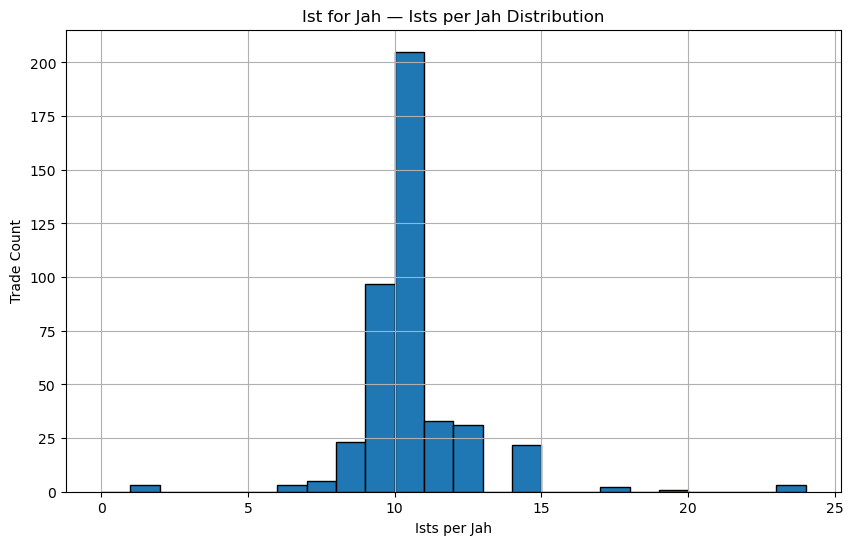

Ist for Jah — Histogram Bins:
Bin 0 - 1: 0 trades
Bin 1 - 2: 3 trades
Bin 2 - 3: 0 trades
Bin 3 - 4: 0 trades
Bin 4 - 5: 0 trades
Bin 5 - 6: 0 trades
Bin 6 - 7: 3 trades
Bin 7 - 8: 5 trades
Bin 8 - 9: 23 trades
Bin 9 - 10: 97 trades
Bin 10 - 11: 205 trades
Bin 11 - 12: 33 trades
Bin 12 - 13: 31 trades
Bin 13 - 14: 0 trades
Bin 14 - 15: 22 trades
Bin 15 - 16: 0 trades
Bin 16 - 17: 0 trades
Bin 17 - 18: 2 trades
Bin 18 - 19: 0 trades
Bin 19 - 20: 1 trades
Bin 20 - 21: 0 trades
Bin 21 - 22: 0 trades
Bin 22 - 23: 0 trades
Bin 23 - 24: 3 trades


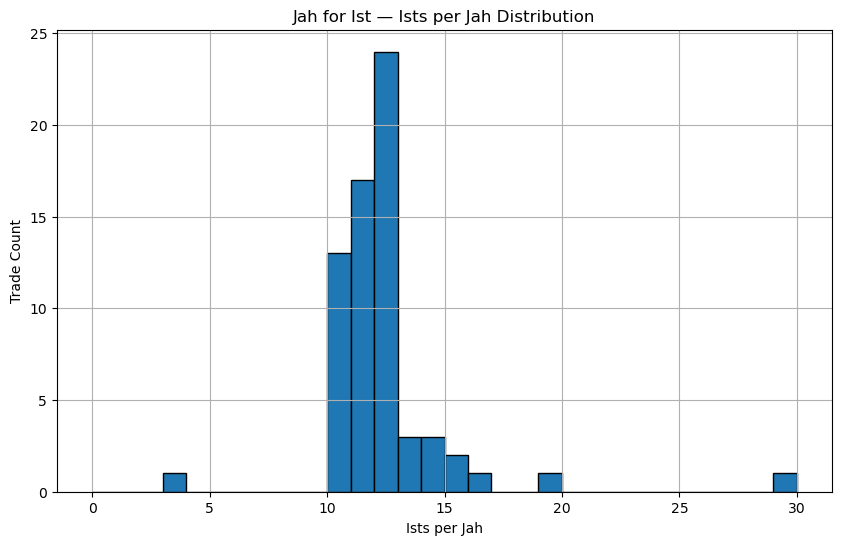


Jah for Ist — Histogram Bins:
Bin 0 - 1: 0 trades
Bin 1 - 2: 0 trades
Bin 2 - 3: 0 trades
Bin 3 - 4: 1 trades
Bin 4 - 5: 0 trades
Bin 5 - 6: 0 trades
Bin 6 - 7: 0 trades
Bin 7 - 8: 0 trades
Bin 8 - 9: 0 trades
Bin 9 - 10: 0 trades
Bin 10 - 11: 13 trades
Bin 11 - 12: 17 trades
Bin 12 - 13: 24 trades
Bin 13 - 14: 3 trades
Bin 14 - 15: 3 trades
Bin 15 - 16: 2 trades
Bin 16 - 17: 1 trades
Bin 17 - 18: 0 trades
Bin 18 - 19: 0 trades
Bin 19 - 20: 1 trades
Bin 20 - 21: 0 trades
Bin 21 - 22: 0 trades
Bin 22 - 23: 0 trades
Bin 23 - 24: 0 trades
Bin 24 - 25: 0 trades
Bin 25 - 26: 0 trades
Bin 26 - 27: 0 trades
Bin 27 - 28: 0 trades
Bin 28 - 29: 0 trades
Bin 29 - 30: 1 trades


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
bin_width = 1
bins = np.arange(0, ist_for_jah['IstsPerJah'].max() + bin_width, bin_width)

# Histogram
counts, bin_edges = np.histogram(ist_for_jah['IstsPerJah'], bins=bins)

plt.figure(figsize=(10, 6))
plt.hist(ist_for_jah['IstsPerJah'], bins=bins, edgecolor='black')
plt.title("Ist for Jah — Ists per Jah Distribution")
plt.xlabel("Ists per Jah")
plt.ylabel("Trade Count")
plt.grid(True)
plt.show()

# Text output per bin
print("Ist for Jah — Histogram Bins:")
for i in range(len(counts)):
    bin_range = f"{bin_edges[i]:.0f} - {bin_edges[i+1]:.0f}"
    print(f"Bin {bin_range}: {counts[i]} trades")

# =============================
# Now repeat for Jah for Ist
# =============================

# Parameters for Jah side
bin_width_jah = 1
bins_jah = np.arange(0, jah_for_ist['IstsPerJah'].max() + bin_width_jah, bin_width_jah)

# Histogram
counts_jah, bin_edges_jah = np.histogram(jah_for_ist['IstsPerJah'], bins=bins_jah)

plt.figure(figsize=(10, 6))
plt.hist(jah_for_ist['IstsPerJah'], bins=bins_jah, edgecolor='black')
plt.title("Jah for Ist — Ists per Jah Distribution")
plt.xlabel("Ists per Jah")
plt.ylabel("Trade Count")
plt.grid(True)
plt.show()

# Text output per bin
print("\nJah for Ist — Histogram Bins:")
for i in range(len(counts_jah)):
    bin_range = f"{bin_edges_jah[i]:.0f} - {bin_edges_jah[i+1]:.0f}"
    print(f"Bin {bin_range}: {counts_jah[i]} trades")

Observation:  Both Ist for Jah and Jah for Ist trades show a strong price cluster between 10–12 Ists per Jah, with most trades concentrated in this range. A small number of outliers exist on both the low side (likely data errors or self-trades) and high side (likely typos or package trades). The bid (Ist for Jah) tends to cluster slightly lower (10), while the ask (Jah for Ist) clusters slightly higher (12), suggesting a natural bid-ask spread of ~2 Ists.

In [25]:
# Apply outlier filter
filtered_ist_for_jah = ist_for_jah[(ist_for_jah['IstsPerJah'] >= 6) & (ist_for_jah['IstsPerJah'] <= 16)]
filtered_jah_for_ist = jah_for_ist[(jah_for_ist['IstsPerJah'] >= 6) & (jah_for_ist['IstsPerJah'] <= 16)]

# VWAP function
def vwap(df):
    return df['IstQty'].sum() / df['JahQty'].sum()

# Split into small (JahQty <= 2) and bulk (JahQty >= 3)
small_ist = filtered_ist_for_jah[filtered_ist_for_jah['JahQty'] <= 2]
bulk_ist = filtered_ist_for_jah[filtered_ist_for_jah['JahQty'] >= 3]

small_jah = filtered_jah_for_ist[filtered_jah_for_ist['JahQty'] <= 2]
bulk_jah = filtered_jah_for_ist[filtered_jah_for_ist['JahQty'] >= 3]

# Compute VWAP for each segment
vwap_small_ist = vwap(small_ist)
vwap_bulk_ist = vwap(bulk_ist)
vwap_small_jah = vwap(small_jah)
vwap_bulk_jah = vwap(bulk_jah)

# Blended FMVs
blended_small = (vwap_small_ist + vwap_small_jah) / 2
blended_bulk = (vwap_bulk_ist + vwap_bulk_jah) / 2

# Output
print("SMALL TRADES:")
print(f"Ist for Jah VWAP: {vwap_small_ist:.2f} Ists per Jah")
print(f"Jah for Ist VWAP: {vwap_small_jah:.2f} Ists per Jah")
print(f"Blended Fair Value: {blended_small:.2f} Ists per Jah")

print("\nBULK TRADES:")
print(f"Ist for Jah VWAP: {vwap_bulk_ist:.2f} Ists per Jah")
print(f"Jah for Ist VWAP: {vwap_bulk_jah:.2f} Ists per Jah")
print(f"Blended Fair Value: {blended_bulk:.2f} Ists per Jah")

SMALL TRADES:
Ist for Jah VWAP: 9.63 Ists per Jah
Jah for Ist VWAP: 11.54 Ists per Jah
Blended Fair Value: 10.59 Ists per Jah

BULK TRADES:
Ist for Jah VWAP: 13.00 Ists per Jah
Jah for Ist VWAP: 12.83 Ists per Jah
Blended Fair Value: 12.92 Ists per Jah


Description:
Filters outliers, segments trades into small (≤2 Jahs) and bulk (≥3 Jahs), then calculates VWAP for each segment and direction. Outputs blended fair values for small and bulk trade sizes.

Results:
	•	Small Trades: 10.59 Ists per Jah
	•	Bulk Trades: 12.92 Ists per Jah

Conclusion:
Bulk trades command a significant premium (~22%) over small trades, reflecting buyer demand for convenience and transaction efficiency.

## Now we apply this to Ber:ist

In [26]:
# Extract Ber:Ist trades (NumAsks == 1)
single_item = df[df['NumAsks'] == 1]

# Separate both directions
ist_for_ber = single_item[
    (single_item['Offered'].str.contains('Ist Rune')) & 
    (single_item['Requested'].str.contains('Ber Rune'))
].copy()

ber_for_ist = single_item[
    (single_item['Offered'].str.contains('Ber Rune')) & 
    (single_item['Requested'].str.contains('Ist Rune'))
].copy()

# Parse quantities
def parse_quantity(s): return int(s.split(':')[1])
ist_for_ber['IstQty'] = ist_for_ber['Offered'].apply(parse_quantity)
ist_for_ber['BerQty'] = ist_for_ber['Requested'].apply(parse_quantity)
ist_for_ber['IstsPerBer'] = ist_for_ber['IstQty'] / ist_for_ber['BerQty']

ber_for_ist['IstQty'] = ber_for_ist['Requested'].apply(parse_quantity)
ber_for_ist['BerQty'] = ber_for_ist['Offered'].apply(parse_quantity)
ber_for_ist['IstsPerBer'] = ber_for_ist['IstQty'] / ber_for_ist['BerQty']

# Apply outlier filter
filtered_ist_for_ber = ist_for_ber[(ist_for_ber['IstsPerBer'] >= 6) & (ist_for_ber['IstsPerBer'] <= 16)]
filtered_ber_for_ist = ber_for_ist[(ber_for_ist['IstsPerBer'] >= 6) & (ber_for_ist['IstsPerBer'] <= 16)]

# VWAP helper with safe handling
def safe_vwap(df):
    qty_sum = df['BerQty'].sum()
    return df['IstQty'].sum() / qty_sum if qty_sum != 0 else None

# Segment into small (≤2 Ber) and bulk (≥3 Ber)
small_ist = filtered_ist_for_ber[filtered_ist_for_ber['BerQty'] <= 2]
bulk_ist = filtered_ist_for_ber[filtered_ist_for_ber['BerQty'] >= 3]

small_ber = filtered_ber_for_ist[filtered_ber_for_ist['BerQty'] <= 2]
bulk_ber = filtered_ber_for_ist[filtered_ber_for_ist['BerQty'] >= 3]

# VWAPs
vwap_small_ist = safe_vwap(small_ist)
vwap_bulk_ist = safe_vwap(bulk_ist)
vwap_small_ber = safe_vwap(small_ber)
vwap_bulk_ber = safe_vwap(bulk_ber)

# Blended (handle None gracefully)
blended_small = (vwap_small_ist + vwap_small_ber) / 2 if vwap_small_ber is not None else vwap_small_ist
blended_bulk = (vwap_bulk_ist + vwap_bulk_ber) / 2 if vwap_bulk_ber is not None else vwap_bulk_ist

# Output
print("SMALL TRADES:")
print(f"Ist for Ber VWAP: {vwap_small_ist:.2f} Ists per Ber")
if vwap_small_ber is not None:
    print(f"Ber for Ist VWAP: {vwap_small_ber:.2f} Ists per Ber")
    print(f"Blended Fair Value: {blended_small:.2f} Ists per Ber")
else:
    print("Ber for Ist VWAP: no trades logged")
    print(f"Blended Fair Value (Ist side only): {blended_small:.2f} Ists per Ber")

print("\nBULK TRADES:")
print(f"Ist for Ber VWAP: {vwap_bulk_ist:.2f} Ists per Ber")
if vwap_bulk_ber is not None:
    print(f"Ber for Ist VWAP: {vwap_bulk_ber:.2f} Ists per Ber")
    print(f"Blended Fair Value: {blended_bulk:.2f} Ists per Ber")
else:
    print("Ber for Ist VWAP: no bulk trades logged")
    print(f"Blended Fair Value (Ist side only): {blended_bulk:.2f} Ists per Ber")

SMALL TRADES:
Ist for Ber VWAP: 8.59 Ists per Ber
Ber for Ist VWAP: 11.22 Ists per Ber
Blended Fair Value: 9.91 Ists per Ber

BULK TRADES:
Ist for Ber VWAP: 12.00 Ists per Ber
Ber for Ist VWAP: no bulk trades logged
Blended Fair Value (Ist side only): 12.00 Ists per Ber


### Jah vs Ber Inferred Price Ratio

Using the blended fair values from bulk trades:

- Jah Bulk Price: **12.92 Ists**
- Ber Bulk Price: **12.00 Ists**

Inferred exchange ratio:

Jah per Ber = 12.92 / 12.00 ≈ 1.08

**Conclusion:**  
Jah trades at approximately an **8% premium** over Ber in bulk trades.

In [30]:
from collections import Counter# Filter: only multi-item trades (NumAsks > 1)
multi_item = df[df['NumAsks'] > 1]

# Filter: only trades that involve both Jah and Ber somewhere
jah_ber_trades = multi_item[
    (multi_item['Offered'].str.contains('Jah Rune') | multi_item['Requested'].str.contains('Jah Rune')) &
    (multi_item['Offered'].str.contains('Ber Rune') | multi_item['Requested'].str.contains('Ber Rune'))
].copy()

# All runes pattern
rune_pattern = r'([A-Za-z]+ Rune):\d+'

# Counter for extra runes
extra_rune_counter = Counter()

for idx, row in jah_ber_trades.iterrows():
    offered_runes = re.findall(rune_pattern, row['Offered'])
    requested_runes = re.findall(rune_pattern, row['Requested'])
    
    total_runes = set(offered_runes + requested_runes)
    extra_runes = total_runes - {'Jah Rune', 'Ber Rune'}
    
    for rune in extra_runes:
        extra_rune_counter[rune] += 1

# Convert to DataFrame for easier viewing
extra_runes_df = pd.DataFrame(extra_rune_counter.items(), columns=['Rune', 'Count'])
extra_runes_df = extra_runes_df.sort_values(by='Count', ascending=False)

print(extra_runes_df)

         Rune  Count
1     Lo Rune    136
0    Ist Rune     49
2    Ohm Rune     49
3   Cham Rune     44
14   Vex Rune     34
22   Amn Rune     33
12   Hel Rune     30
23   Ral Rune     30
21   Pul Rune     22
15   Mal Rune     22
18   Lem Rune     18
4    Sur Rune     17
8    Eth Rune     16
10   Gul Rune      9
11   Zod Rune      6
5    Dol Rune      6
19   Nef Rune      5
20   Ort Rune      5
6    Eld Rune      3
17    Ko Rune      3
9    Fal Rune      3
7     El Rune      3
16    Um Rune      2
13   Ith Rune      1


In [31]:
# filename: jah_ber_lo_model.ipynb

import pandas as pd
import re
import numpy as np
from sklearn.linear_model import LinearRegression

# Load data
file_path = '/Users/buddy/Desktop/traderie/data/normalized/normalized_trades_pc_sc_nl.csv'
df = pd.read_csv(file_path)

# Filter: multi-item trades involving Jah, Ber, and Lo
multi_item = df[df['NumAsks'] > 1]

jah_ber_lo = multi_item[
    (multi_item['Offered'].str.contains('Jah Rune') | multi_item['Requested'].str.contains('Jah Rune')) &
    (multi_item['Offered'].str.contains('Ber Rune') | multi_item['Requested'].str.contains('Ber Rune')) &
    (multi_item['Offered'].str.contains('Lo Rune') | multi_item['Requested'].str.contains('Lo Rune'))
].copy()

# Extraction function
def extract_qty(field, rune):
    match = re.findall(fr'{rune}:(\d+)', field)
    return sum(int(qty) for qty in match) if match else 0

# Build dataset
records = []
for idx, row in jah_ber_lo.iterrows():
    offered = row['Offered']
    requested = row['Requested']
    
    jah_off = extract_qty(offered, 'Jah Rune')
    jah_req = extract_qty(requested, 'Jah Rune')
    ber_off = extract_qty(offered, 'Ber Rune')
    ber_req = extract_qty(requested, 'Ber Rune')
    lo_off = extract_qty(offered, 'Lo Rune')
    lo_req = extract_qty(requested, 'Lo Rune')
    
    net_jah = jah_off - jah_req
    net_ber = ber_off - ber_req
    net_lo  = lo_off - lo_req
    
    # We only keep valid Jah <> Ber swaps (both non-zero directions)
    if net_jah != 0 and net_ber != 0:
        records.append({'NetJah': net_jah, 'NetBer': net_ber, 'NetLo': net_lo})

# Create DataFrame
eq_df = pd.DataFrame(records)

# Build linear system: JahQty = BerQty + X * LoQty
Y = eq_df['NetJah'].values
X = np.column_stack([eq_df['NetBer'].values, eq_df['NetLo'].values])

# Target is Jah, Ber is fixed 1, Lo coefficient is unknown
# So subtract Ber from Jah to isolate Lo coefficient
Y_adjusted = Y - X[:, 0]  # JahQty - BerQty

# Linear regression: Y_adjusted = X_lo * LoValue
reg = LinearRegression(fit_intercept=False)
reg.fit(X[:, 1].reshape(-1, 1), Y_adjusted)

lo_value = reg.coef_[0]

print(f"Estimated Lo value relative to Ber: {lo_value:.4f}")
print(f"Jah = Ber + {lo_value:.4f} * Lo")

Estimated Lo value relative to Ber: 0.3327
Jah = Ber + 0.3327 * Lo


In [32]:
# filename: show_jah_ber_lo_trades.ipynb

import pandas as pd
import re

# Load data
file_path = '/Users/buddy/Desktop/traderie/data/normalized/normalized_trades_pc_sc_nl.csv'
df = pd.read_csv(file_path)

# Filter: trades with Jah or Ber on both sides, and Lo involved somewhere
def has_jah_or_ber(text):
    return bool(re.search(r'(Jah Rune|Ber Rune)', text))

def has_lo(text):
    return 'Lo Rune' in text

filtered_trades = df[
    (
        (df['Offered'].apply(has_jah_or_ber)) & 
        (df['Requested'].apply(has_jah_or_ber)) & 
        (
            df['Offered'].apply(has_lo) | 
            df['Requested'].apply(has_lo)
        )
    )
].copy()

# Show a sample of the trades
print(filtered_trades[['TradeID', 'Offered', 'Requested']].head(20))

# Optionally: count how many trades matched
print(f"\nTotal matching trades: {len(filtered_trades)}")

                                TradeID      Offered  \
1031  Ber Rune_2025-05-30T12:58:12.449Z   Ber Rune:1   
1049  Ber Rune_2025-05-31T09:38:25.441Z   Ber Rune:1   
1158  Ber Rune_2025-06-03T01:25:27.485Z   Ber Rune:1   
1160  Ber Rune_2025-06-03T00:56:24.591Z   Ber Rune:1   
1165  Ber Rune_2025-06-02T22:02:47.463Z   Ber Rune:1   
1173  Ber Rune_2025-06-02T17:39:19.234Z   Ber Rune:1   
1178  Ber Rune_2025-06-02T15:53:35.109Z   Ber Rune:1   
1208  Ber Rune_2025-06-04T00:06:20.010Z   Ber Rune:1   
1444  Ber Rune_2025-06-08T04:21:09.960Z   Ber Rune:1   
1450  Ber Rune_2025-06-08T01:49:53.254Z  Ber Rune:17   
1477  Ber Rune_2025-06-09T12:52:20.871Z   Ber Rune:1   
1497  Ber Rune_2025-06-11T01:31:20.189Z   Ber Rune:1   
5323  Jah Rune_2025-05-20T22:18:14.245Z   Jah Rune:1   
5324  Jah Rune_2025-05-20T22:04:54.460Z   Jah Rune:1   
5328  Jah Rune_2025-05-20T14:05:18.486Z   Jah Rune:4   
5335  Jah Rune_2025-05-20T04:47:49.378Z   Jah Rune:1   
5358  Jah Rune_2025-05-21T07:56:01.027Z   Jah Ru